# <span style="color:green"> Lecture 08 notebook </span>

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import math
from matplotlib.colors import LogNorm
from matplotlib.colors import SymLogNorm


L'obiettivo di questa esercitazione è ottimizzare, tramite il principio variazionale, il _ground state_ di una particella confinata da un potenziale unidimensionale della forma 
$$
V(x) = x^4 - \frac{5}{2}x^2.
$$

Per risolvere il problema numericamente, è stata utilizzata una funzione di prova 

$$
\Psi_T^{\sigma,\mu}(x) \propto e^{-\frac{(x-\mu)^2}{2\sigma^2}}+ e^{-\frac{(x+\mu)^2}{2\sigma^2}},
$$
 che dipende da due parametri variazionali: $\sigma$ e $\mu$.
 


## <span style="color:blue">  Exercise 08.1 </span>

Per lo svolgimento di questo esercizio, ho scritto un codice che calcoli il valore di aspettazione dell'Hamiltoniana 

$$
\langle {\hat H} \rangle_T = 
\frac{\int dx \Psi^*_T(x) {\hat H} \Psi_T(x)}
{\int dx |\Psi_T(x)|^2} = 
\int dx \frac{|\Psi_T(x)|^2}{\int dx |\Psi_T(x)|^2} \frac{{\hat H} \Psi_T(x)}{\Psi_T(x)}
$$

Per l'esercizio sono stati utilizzati $M=100$ blocchi, ciascuno di $L=5000$ passi. I parametri utilizzati sono stati $\mu = 0.7$ e $\sigma = 0.6$.
Il $\delta$, parametro che rappresenta l'ampiezza del passo del Metropolis, è stato impostato a $2.5$, in modo da ottenere un'accettazione intorno al valore ideale di $0.5$. Ho utilizzato questo valore anche per l'esercizio successivo, illustrando anche la progressione del valore di accettazione.

Valore stimato di H -0.401556
Incertezza 0.00143585


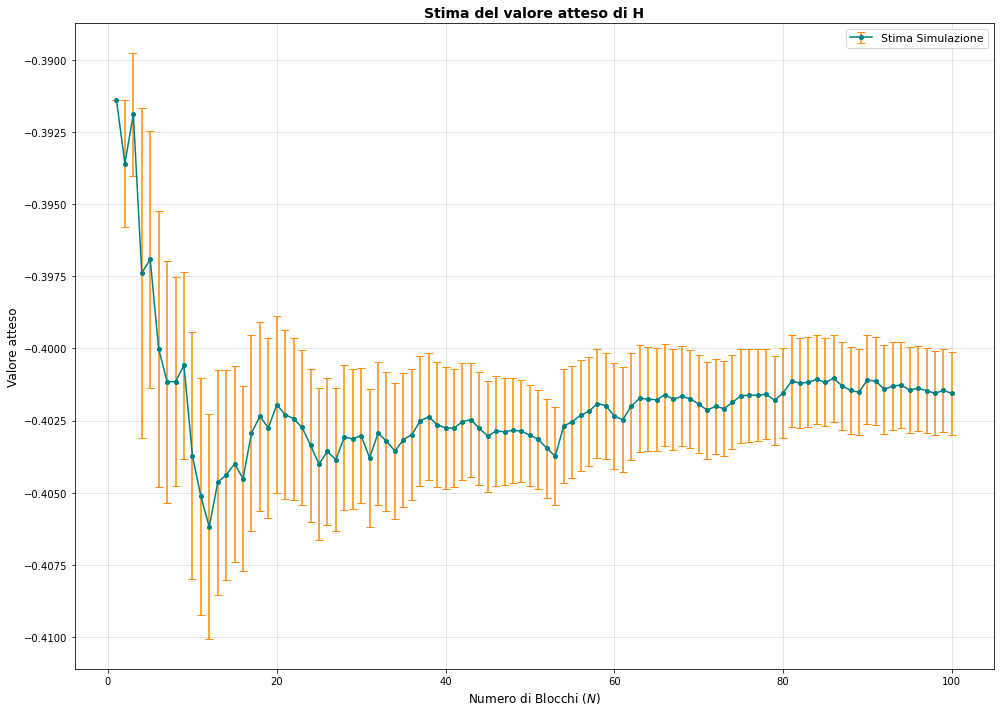

In [21]:
H_prog, err_prog = np.loadtxt("Hvalue.txt", unpack = True)

N = len(H_prog)
blocks = np.arange(1, N + 1)

print("Valore stimato di H", H_prog[-1])
print("Incertezza", err_prog[-1])


plt.figure(figsize=(14, 10))


plt.errorbar(blocks, H_prog, yerr=err_prog, fmt='o-', color='teal', 
             ecolor='darkorange', elinewidth=1.5, capsize=4, markersize=4, label='Stima Simulazione')


plt.title(r"Stima del valore atteso di H", fontsize=14, fontweight='bold')
plt.xlabel("Numero di Blocchi ($N$)", fontsize=12)
plt.ylabel(r"Valore atteso", fontsize=12)
plt.grid(True, alpha=0.4)
plt.legend(loc='best', fontsize=11)

plt.tight_layout()
plt.show()

## <span style="color:blue">  Exercise 08.2 </span>

Dopo diversi tentativi, ho scelto questa organizzazione per il mio codice di simulated annealing:


## <span style="color:black">  Temperatura </span>

- Temperatura di partenza: 0.2
- Evoluzione esponenziale: ogni aggiornamento di temperatura viene compiuto secondo la legge $T_{new} = 0.85\cdot T_{old}$. Ho fatto diversi tentativi, e alla fine ho scelto il valore di $0.85$ come fattore moltiplicativo perché mi permette di far diminuire la temperatura abbastanza rapidamente, mantenendo un'evoluzione del tasso di accettazione che mi piaceva, molto alto all'inizio e decrescente fino ad essere prossimo allo $0$ negli ultimi blocchi. Documentandomi, ho trovato che una moltiplicazione per $0.85$ è il limite inferiore del range di valori consigliati per questo tipo di operazione. Per una buca di potenziale così semplice, però, ho preferito una diminuzione rapida della temperatura per avere tanti passaggi vicino al minimo, e ho sopperito con il parametro $\delta$, ovvero lo spostamento proposto nello spazio delle fasi, regolando i due parametri in modo da tenere l'accettazione a livelli ragionevoli.
- 40 valori di temperatura sperimentati nell'arco di un simulated annealing: anche qui, non penso ci sia una scelta giusta, ma provando mi è sembrato un compromesso ragionevole tra durata dell'esecuzione e precisione desiderata.

## <span style="color:black">  Iterazioni </span>

Questo parametro rappresenta il numero di iterazioni eseguite, cioè di mosse proposte e valutate, a una data temperatura. Ho scelto di partire con $10$ iterazioni, per aumentarle gradualmente, aggiungendone $2$ ad ogni aggiornamento del valore di $T$. Questo mi ha permesso di velocizzare il codice nelle prime fasi, quando l'accettazione è molto alta, e di aumentare il numero di tentativi una volta che ci troviamo nei pressi dell'ottimo. Per l'ultimo valore di temperatura, dunque, sono state eseguite $90$ iterazioni

## <span style="color:black">  Metropolis interno</span>

I parametri del Metropolis interno al ciclo, che restituisce il valore di energia per i nuovi parametri proposti, sono stati aggiornati gradualmente con la temperatura, ancora una volta per coniugare efficienza del codice e precisione nella ricerca dell'ottimo. 

Il campionamento di ciascun Monte Carlo è composto inizialmente da:
- L = 2000 mosse;
- M = 30 blocchi.

Il numero dei blocchi $M$ è stato aumentato di $1$ ad ogni variazione della temperatura, per ridurre l'incertezza associata al valore della temperatura. Come illustrato in seguito, infatti, mi sono accorto che l'ottimizzazione è molto sensibile alle fluttuazioni statistiche del calcolo del valore di aspettazione dell'energia per le mosse proposte, e quindi alla fine dell'evoluzione, quando le mosse sono ormai piccole e le differenze di energia risibili, è richiesta la massima precisione. Per questo motivo, aumentare il numero dei blocchi al ridursi della temperatura migliora significativamente le prestazioni dell'algoritmo e permette di risparmiare tempo nelle fasi inziali dell'evoluzione.

Il valore $\delta_{int}$, ovvero la lunghezza del passo del Metropolis, è stato regolato ad un valore di $2.5$ in modo da mantenere un valore di accettazione intorno al $50\%$ per tutte le run aseguito di sperimentazioni compiute nell'Esercizio 8.1.

## <span style="color:black">  Metropolis esterno </span>

Per quanto riguarda il parametro $\delta_{ext}$, cioè la variazione nei parametri $\mu$ e $\sigma$ proposta a ogni ciclo del Metropolis esterno, sono partito da un valore di $0.1$, riducendolo secondo la legge $\delta_{new} = 0.95 \cdot \delta_{old}$. 

L'idea, come per la temperatura, è quella di far fare mosse grandi al sistema nella fase iniziale, quando la temperatura è ancora alta e quindi anche una grande variazione di energia può essere sostenibile dal punto di vista dell'accettazione, per ridurre gradualmente l'ampiezza dei "passi" nello spazio dei parametri all'abbassarsi della temperatura, cercando variazioni molto piccole che possano condurre al perfezionamento della posizione ottimale una volta che la zona del minimo è stata identificata. 

I valori precisi sono stati scelti empiricamente, in accordo alle scelte sulla temperatura, per ottenere una progressione gradita dei valori di accettazione.

Ovviamente, il passo $\delta_{ext}$ selezionato può essere ridotto o aumentato a piacimento, così come il valore assoluto della temperatura, anche a seconda delle procedure preliminari svolte: per metterlo alla prova in tutte le situazioni ho scelto di far partire l'algoritmo volutamente lontano dalla zona del minimo nello spazio dei parametri, ma se a seguito di analisi preliminari si fosse ragionevolmente certi  di stare partendo più vicini sarebbero probabilmente ottimali scelte diverse, riducendo il passo e il valore di temperatura, e aumentando fin da subito (e sensibilmente) il numero dei blocchi utilizzati per il Metropolis interno.

## <span style="color:black">  Accettazione </span>

Per quanto riguarda l'accettazione, nel grafico sottostante sono riportati i valori di accettazione per ogni run di Metropolis, in funzione della temperatura, sia per il Metropolis esterno che per quello interno. 

Per quanto riguarda il Metropolis interno, ho cercato di mantenere un'accettazione intorno al valore ottimale del $50\%$. 

Per quanto riguarda il Metropolis esterno, invece, possiamo osservare come da un'accettazione molto alta ad alta temperatura (ho modulato i valori in modo da evitare di avere più blocchi ad accettazione $1$, perché mi sembrava uno spreco), si arrivi ad un'accettazione nulla per gli ultimi valori di temperatura. Questo è un sacrificio computazionale che mi sembra accettabile per avere una relativa certezza di trovarci davvero nel minimo. Non mi sarei fidato ad accettare un valore in continua variazione o appena stabilizzatosi.

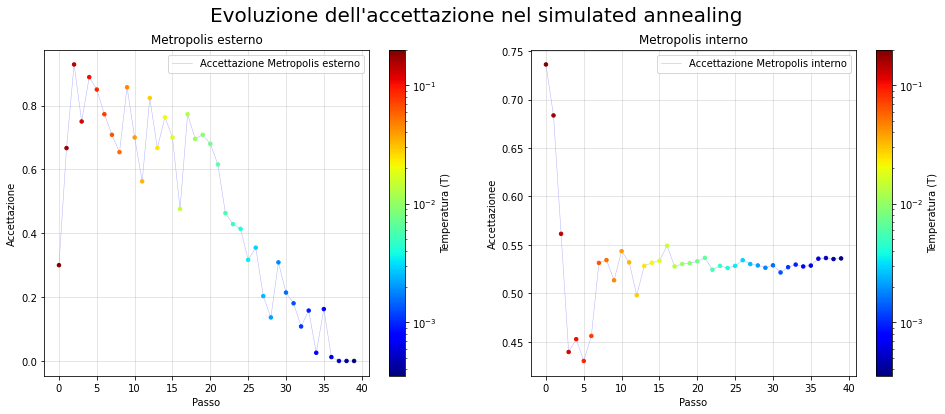

In [8]:
acc_ext, acc_int = np.loadtxt("acceptance.txt", usecols = (0, 1), unpack = True)

N = len(acc_ext)
x = np.arange(N)

T_list2 = []
t = 0.2
alfa = 0.85
iterations = 10

for j in range(50):
    T_list2.append(t)
    t *= alfa

T_list2 = T_list2[:len(acc_ext)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(x, acc_ext, color='blue', linewidth=0.5, alpha=0.3, zorder = 1, label='Accettazione Metropolis esterno')
scatter_e0 = axes[0].scatter(x, acc_ext, c=T_list2, cmap='jet', norm=LogNorm(), s=12, zorder=2)
axes[0].set_title("Metropolis esterno")
axes[0].set_xlabel("Passo")
axes[0].set_ylabel("Accettazione")
axes[0].grid(True, alpha=0.4)
axes[0].legend()
fig.colorbar(scatter_e0, ax=axes[0], label='Temperatura (T)')

axes[1].plot(x, acc_int, color='blue', linewidth=0.5, alpha=0.3, zorder = 1, label='Accettazione Metropolis interno')
scatter_e1 = axes[1].scatter(x, acc_int, c=T_list2, cmap='jet', norm=LogNorm(), s=12, zorder=2)
axes[1].set_title("Metropolis interno")
axes[1].set_xlabel("Passo")
axes[1].set_ylabel("Accettazionee")
axes[1].grid(True, alpha=0.4)
axes[1].legend()
fig.colorbar(scatter_e1, ax=axes[1], label='Temperatura (T)')


plt.suptitle("Evoluzione dell'accettazione nel simulated annealing", fontsize=20, y=0.98)
plt.show()

Energia del ground state stimata:  -0.451628
Errore:  0.00196793


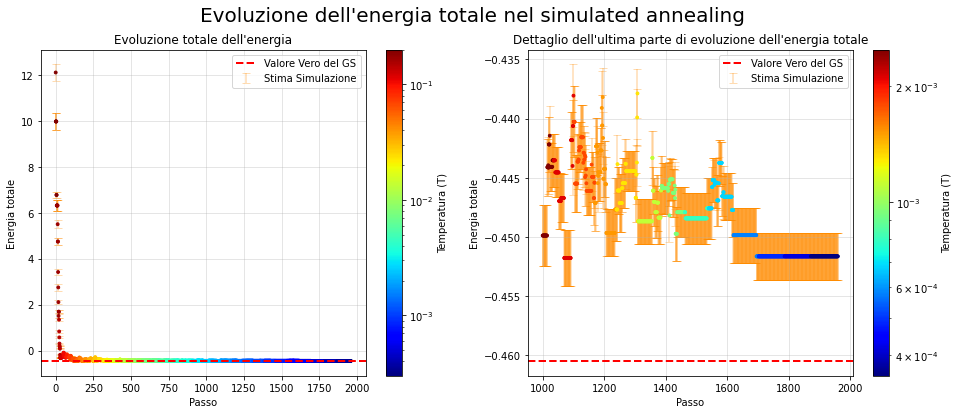

In [9]:

energy, error = np.loadtxt("parameters.txt", usecols = (2, 3), unpack = True)

final_energy = energy[-1]

N = len(energy)
x = np.arange(N)

T_list = []
t = 0.2
alfa = 0.85
iterations = 10

for j in range(50):
    for i in range(iterations):
        T_list.append(t)
    
    t *= alfa
    #if j % 5 == 0 and j != 0:
    iterations += 2

T_list = T_list[:len(energy)]

print("Energia del ground state stimata: ", energy[-1])
print("Errore: ", error[-1])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

true = -0.46046587969271513

axes[0].errorbar(x, energy, yerr = error, fmt='none', color='gray', 
             ecolor='darkorange', elinewidth=1.5, capsize=4, markersize=4, zorder = 1, alpha = 0.3, label='Stima Simulazione')
scatter_e0 = axes[0].scatter(x, energy, c=T_list, cmap='jet', norm=LogNorm(), s=8, zorder=2)
axes[0].axhline(true, color='red', linestyle='--', linewidth=2, label="Valore Vero del GS")
axes[0].set_title("Evoluzione totale dell'energia")
axes[0].set_xlabel("Passo")
axes[0].set_ylabel("Energia totale")
axes[0].grid(True, alpha=0.4)
axes[0].legend()
fig.colorbar(scatter_e0, ax=axes[0], label='Temperatura (T)')

axes[1].errorbar(x[1000: -1], energy[1000:-1], yerr = error[1000:-1], fmt='none', color='gray', 
             ecolor='darkorange', elinewidth=1.5, capsize=4, markersize=4, zorder = 1, alpha = 0.3, label='Stima Simulazione')
scatter_e1 = axes[1].scatter(x[1000:-1], energy[1000:-1], c=T_list[1000:-1], cmap='jet', norm=LogNorm(), s=8, zorder=2)
axes[1].axhline(true, color='red', linestyle='--', linewidth=2, label="Valore Vero del GS")
axes[1].set_title("Dettaglio dell'ultima parte di evoluzione dell'energia totale")
axes[1].set_xlabel("Passo")
axes[1].set_ylabel("Energia totale")
axes[1].grid(True, alpha=0.4)
axes[1].legend()
fig.colorbar(scatter_e1, ax=axes[1], label='Temperatura (T)')


plt.suptitle("Evoluzione dell'energia totale nel simulated annealing", fontsize=20, y=0.98)
plt.show()

Possiamo osservare come il sistema, nonostante non sia strettamente necessario nel nostro caso (aveva già raggiunto il minimo e se ne è allontanato, come osservabile nella figura di destra) non rimanga totalmente fisso nello stesso posto fino agli ultimissimi valori di temperatura, continuando ad esplorare lo spazio delle fasi. Questo comportamento è perfettamente esemplicativo del funzionamento dello stochastic gradient descent, che permette di lasciare minimi locali per esplorare regioni di spazio diverse, comportamento che nel caso di minimi più complessi potrebbe risultare molto utile.

Inoltre, possiamo osservare l'attualizzazione del principio variazionale della meccanica quantistica: il nostro algoritmo, nonostante l'ottimizzazione dei parametri $\mu$ e $\sigma$, avendo utilizzato una funzione d'onda di prova calcola sempre un valore di aspettazione dell'energia superiore a $E_0$.

Miglior valore di σ: 0.62453
Miglior valore di μ: 0.818955


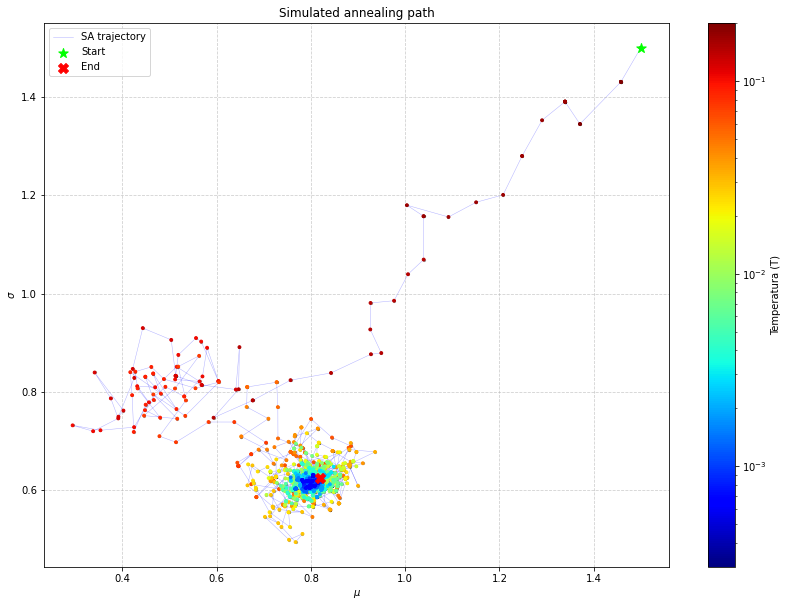

In [18]:
plt.figure(figsize=(14, 10))

mu, sigma = np.loadtxt("parameters.txt", usecols = (0, 1), unpack = True)

plt.plot(mu, sigma, color='blue', linewidth=0.5, alpha=0.3, zorder = 1, label='SA trajectory')

plt.scatter(mu, sigma, color='black', s=5, alpha=0.3)

plt.scatter(mu[0], sigma[0], color='lime', s=100, marker='*', zorder = 5, label='Start')

print('Miglior valore di σ:', sigma[-1])
print('Miglior valore di μ:', mu[-1])
plt.scatter(mu[-1], sigma[-1], color='red', s=100, marker='X', zorder = 5, label='End')
scatter_e = plt.scatter(mu, sigma, c=T_list, cmap='jet', norm=LogNorm(), s=8, zorder=2)
plt.title("Simulated annealing path")
plt.xlabel(r'$\mu$')
plt.ylabel(r'$\sigma$')
plt.colorbar(scatter_e, label='Temperatura (T)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.plot();

Nella figura sottostante sono rappresentati i valori assunti dalla funzione energia nella stessa porzione di spazio dei parametri rappresentata nel grafico precedente. Ho saturato la scala dei colori sopra $-0.20$ per rendere più evidente la buca del minimo. Per poter rappresentare valori negativi di aspettazione dell'energia in scala logaritmica, necessario per osservare i cambiamenti vicino al minimo, ho utilizzato una funzione che linearizza il logaritmo intorno allo zero, selezionando una _lintresh_ simmetrica intorno allo 0 in corrispondenza dei valori $\pm 0.46$.

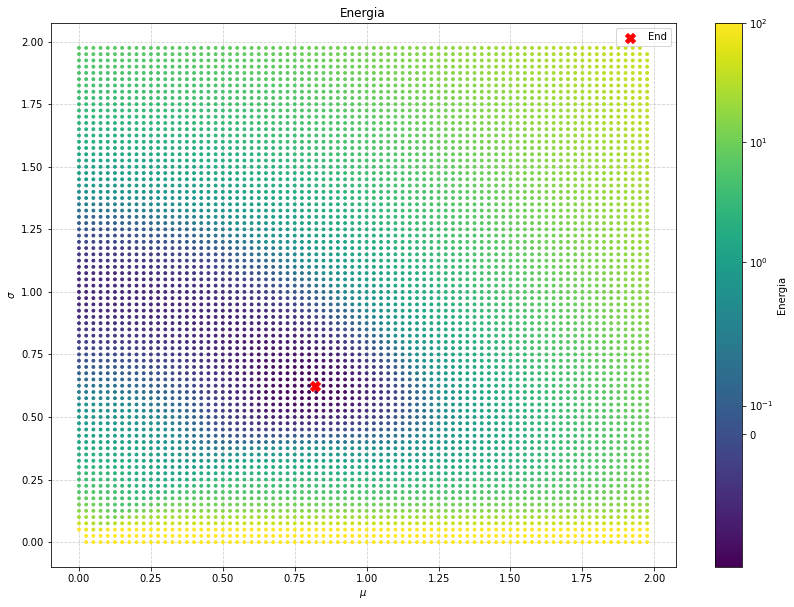

In [19]:
plt.figure(figsize=(14, 10))


mu_v, sigma_v, energy_v = np.loadtxt("values_grid.txt", usecols = (0, 1, 2), unpack = True)
energy_v = np.nan_to_num(energy_v, nan=100.0)

plt.scatter(mu[-1], sigma[-1], color='red', s=100, marker='X', zorder = 5, label='End')
scatter_e = plt.scatter(mu_v[2:-1], sigma_v[2:-1], c=energy_v[2:-1], cmap='viridis', norm=SymLogNorm(linthresh=0.46, vmin=-0.46, vmax=100), s=8, zorder=2)
plt.title("Energia")
plt.xlabel(r'$\mu$')
plt.ylabel(r'$\sigma$')
plt.colorbar(scatter_e, label='Energia')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.plot();

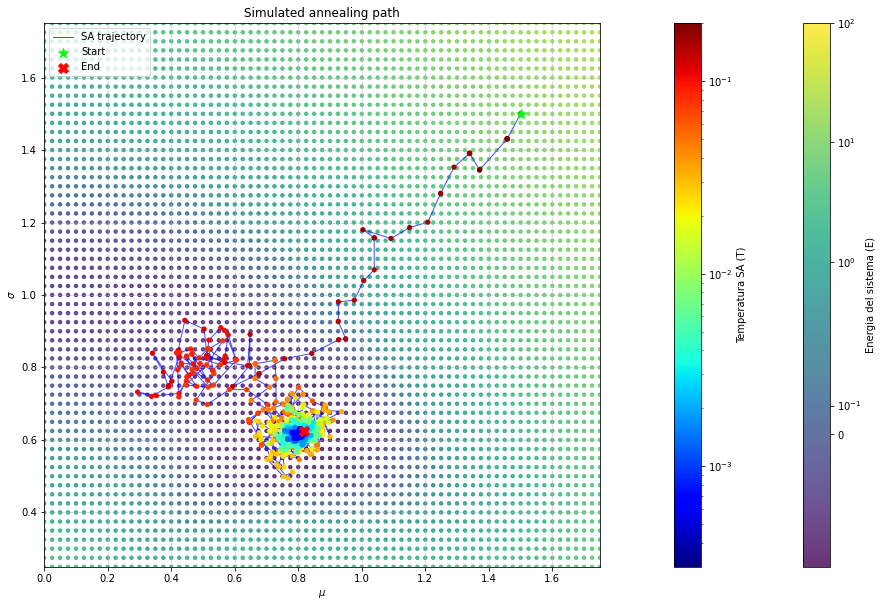

In [22]:
plt.figure(figsize=(16, 10))

scatter_E = plt.scatter(mu_v, sigma_v, c=energy_v, cmap='viridis', norm=SymLogNorm(linthresh=0.46, vmin=-0.46, vmax=100), s=12, alpha = 0.8, zorder=0)
plt.plot(mu, sigma, color='blue', linewidth=1, alpha=0.7, zorder = 1, label='SA trajectory')

scatter_T = plt.scatter(mu, sigma, c=T_list, cmap='jet', norm=LogNorm(), s=18, zorder=2)

plt.scatter(mu[0], sigma[0], color='lime', s=100, marker='*', zorder = 5, label='Start')

plt.scatter(mu[-1], sigma[-1], color='red', s=100, marker='X', zorder = 5, label='End')


plt.title("Simulated annealing path")
plt.xlabel(r'$\mu$')
plt.ylabel(r'$\sigma$')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(0.0, 1.75)  
plt.ylim(0.25, 1.75)

cbar_E = plt.colorbar(scatter_E, pad=0.02)
cbar_E.set_label('Energia del sistema (E)')

cbar_T = plt.colorbar(scatter_T, pad=0.1)
cbar_T.set_label('Temperatura SA (T)') 
plt.legend(loc = 'upper left')
plt.plot();

Nella figura possiamo osservare la rapida discesa verso la "valle" del minimo, condotta in pochi passi e con un valore di $\delta$ molto elevato.

Osserviamo anche la localizzazione temporanea in un punto lontano dal minimo reale, che viene successivamente abbandonata all'abbassarsi ulteriore della temperatura. 

Prima della metà del processo di raffreddamento il sistema si trova già nella zona del minimo: possiamo osservare la netta riduzione del passo $\delta$, per aumentare la precisione nella ricerca del minimo a basse temperature.

Energia del ground state stimata:  -0.444141
Errore:  0.00276849


[]

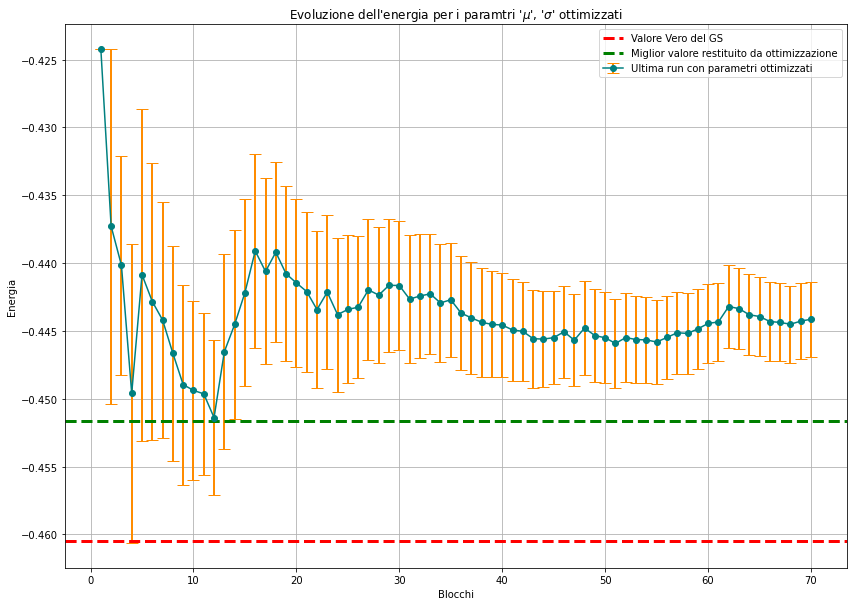

In [27]:
plt.figure(figsize=(14, 10))
energy, error = np.loadtxt("Optimized_energy_evolution.txt", usecols = (0, 1), unpack = True)

N = len(energy)
x = np.arange(1,N+1)

print("Energia del ground state stimata: ", energy[-1])
print("Errore: ", error[-1])

true = -0.46046587969271513
plt.errorbar(x, energy, yerr = error, fmt='o-', color='teal', ecolor='darkorange', elinewidth=2, capsize=6, markersize=6, label='Ultima run con parametri ottimizzati')
plt.axhline(true, color='red', linestyle='--', linewidth=3, label="Valore Vero del GS")
plt.axhline(final_energy, color='green', linestyle='--', linewidth=3, label="Miglior valore restituito da ottimizzazione")
plt.grid(True)
plt.title(r"Evoluzione dell'energia per i paramtri '$\mu$', '$\sigma$' ottimizzati")
plt.xlabel("Blocchi")
plt.ylabel("Energia")
plt.legend()
plt.plot()

Osserviamo che il valore ottenuto con i parametri ottimizzati si discosta dal valore finale dell'energia restituito dal processo di ottimizzazione di più di $2\sigma$, ed è costantemente (su più tentativi) meno negativo di quest'ultimo. La spiegazione di questo fenomeno risiede nel fatto che le due variabili non sono gaussianamente distribuite una sull'altra: il simulated annealing rimane "intrappolato" su trial che hanno avuto un errore al ribasso, che statisticamente, date le molte iterazioni, occorrono. Da qui nasce l'esigenza di aumentare il numero dei blocchi man mano che la temperatura decresce nel simulated annealing, cercando di ridurre la deviazione standard dei valori di energia restituiti, e dunque di evitare di seguire "piste false", dettate da un errore significativo al ribasso. 
Dunque, è ragionevole che l'ultima run, ottenuta coi parametri ottimizzati, esibisca costantemente un valore nettamente maggiore del valore finale del simulated annealing, dal momento che quest'ultimo è quasi certamente un caso che ha avuto una straordinaria variazione al ribasso nella stima del valor medio.

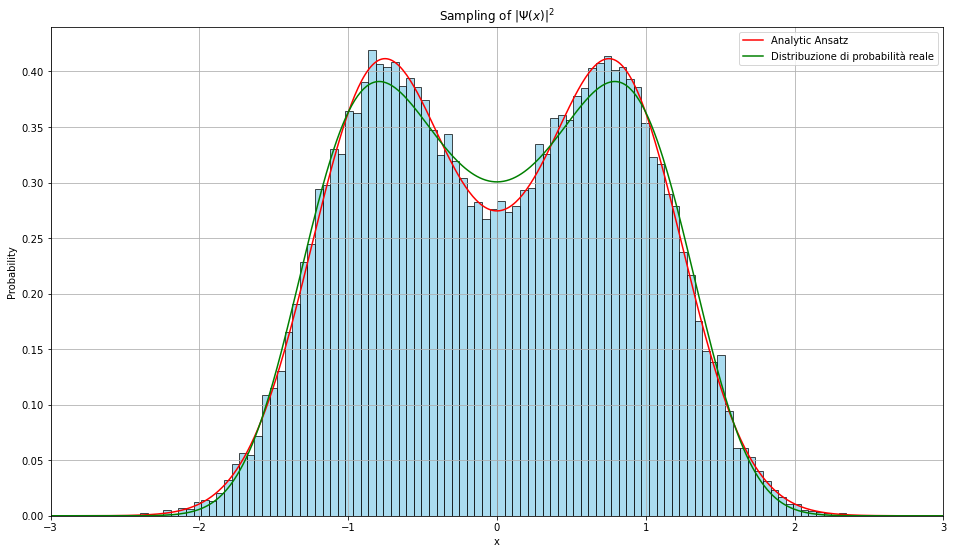

In [17]:
def psi2_analitica(x, mu, sigma):
    norm = 2 * sigma * np.sqrt(np.pi) * (1 + np.exp(-(mu**2)/(sigma**2)))
    psi = np.exp(-(x-mu)**2/(2*sigma**2)) + np.exp(-(x+mu)**2/(2*sigma**2))
    return (psi**2) / norm

def Vpot(x):
    return (x**2 - 2.5)*x**2
    #return 0.5*x**2

hbar = 1
m = 1
a = 10
N = 1000 # number of iterations

# Step sizes
x = np.linspace(-a/2, a/2, N)
dx = x[1] - x[0] # the step size
V = Vpot(x)

# The central differences method: f" = (f_1 - 2*f_0 + f_-1)/dx^2

CDiff = np.diag(np.ones(N-1),-1)-2*np.diag(np.ones(N),0)+np.diag(np.ones(N-1),1)
# np.diag(np.array,k) construct a "diagonal" matrix using the np.array
# The default is k=0. Use k>0 for diagonals above the main diagonal, 
# and k<0 for diagonals below the main diagonal

# Hamiltonian matrix
H = (-(hbar**2)*CDiff)/(2*m*dx**2) + np.diag(V)

# Compute eigenvectors and their eigenvalues
E,psi = np.linalg.eigh(H)

# Take the transpose & normalize
psi = np.transpose(psi)
psi = psi/np.sqrt(dx)

density = np.loadtxt("Histo.txt", usecols = 0, unpack = True)
x_lin = np.linspace(-3, 3, 500)

plt.figure(figsize=(16,9))

plt.plot(x_lin, psi2_analitica(x_lin, mu[-1], sigma[-1]), label='Analytic Ansatz', color='red')
plt.plot(x,(psi[0])**2, color='green', label= 'Distribuzione di probabilità reale')
plt.hist(density, bins=100, density=True, alpha=0.7, color='skyblue', edgecolor='black')

plt.xlim((-3,3))
plt.title(r'Sampling of $|\Psi(x)|^2$')
plt.xlabel('x')
plt.ylabel('Probability')
plt.legend()
plt.grid(True)
plt.show()